In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder,OrdinalEncoder


In [6]:
df=pd.read_csv("turkcell_yorumlari.csv")
df.head()

,Yorum,Puan,Tarih,Kullanıcı
0,çok guzeldir,5,2026-01-27 13:15:50,Google kullanıcısı
1,3 yıldır kullanıyorum 27 01 2026 da müşteri hi...,1,2026-01-27 11:40:16,Google kullanıcısı
2,güzel beğendin,5,2026-01-27 11:12:33,Google kullanıcısı
3,çekim gücü zayıf,1,2026-01-27 10:07:51,Google kullanıcısı
4,👍,5,2026-01-27 09:40:04,Google kullanıcısı


In [7]:
df.columns

Index(['Yorum', 'Puan', 'Tarih', 'Kullanıcı'], dtype='object')

In [8]:
df.shape

(209949, 4)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209949 entries, 0 to 209948
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Yorum      209875 non-null  object
 1   Puan       209949 non-null  int64 
 2   Tarih      209949 non-null  object
 3   Kullanıcı  209949 non-null  object
dtypes: int64(1), object(3)
memory usage: 6.4+ MB


In [10]:
df.describe()

,Puan
count,209949.000000
mean,3.547895
std,1.812712
min,1.000000
25%,1.000000
50%,5.000000
75%,5.000000
max,5.000000


In [11]:
df.isnull().sum()

Yorum        74
Puan          0
Tarih         0
Kullanıcı     0
dtype: int64

In [12]:
df["Puan"].value_counts()

Puan
5    119814
1     64068
4     10454
3      8697
2      6916
Name: count, dtype: int64

In [13]:
df["Kullanıcı"].value_counts()

Kullanıcı
Google kullanıcısı    208922
Neslihan Çavdar            2
Serkan Özdemir             1
hasan yamaner              1
Hamza Avci                 1
                       ...  
Fadime Tanrıverdi          1
Nejla Yüksel               1
Seher K                    1
Shahed Kejjih              1
Ahmet Karakaya             1
Name: count, Length: 1027, dtype: int64

In [14]:
df.drop('Kullanıcı', axis=1, inplace=True)

In [15]:
df.head()

,Yorum,Puan,Tarih
0,çok guzeldir,5,2026-01-27 13:15:50
1,3 yıldır kullanıyorum 27 01 2026 da müşteri hi...,1,2026-01-27 11:40:16
2,güzel beğendin,5,2026-01-27 11:12:33
3,çekim gücü zayıf,1,2026-01-27 10:07:51
4,👍,5,2026-01-27 09:40:04


In [16]:
silinecek_indexler = df[df['Puan'] == 3].index

In [17]:
df.drop(silinecek_indexler, inplace=True)

In [18]:
df['Puan'].value_counts()


Puan
5    119814
1     64068
4     10454
2      6916
Name: count, dtype: int64

<Axes: xlabel='Puan', ylabel='count'>

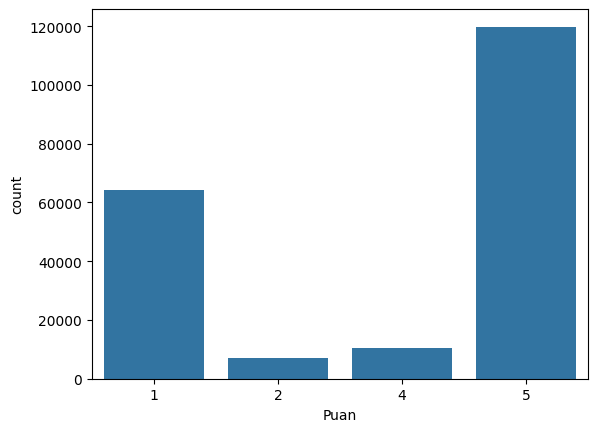

In [19]:
plt.Figure(figsize=(10,6))
sns.countplot(x='Puan',data=df)

C:\Users\aalim\AppData\Local\Temp\ipykernel_5004\2213959581.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  aylik_ortalama = df.resample('M', on='Tarih')['Puan'].mean()


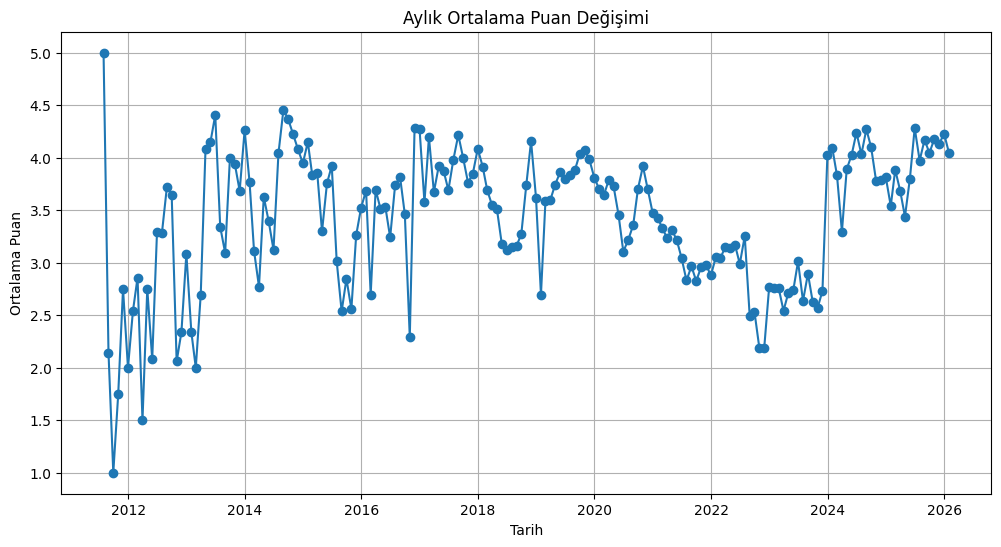

In [20]:
# Önce Tarih sütununu gerçek tarih formatına çevirdiğinden emin ol
df['Tarih'] = pd.to_datetime(df['Tarih'])

# Aylık ortalama puanı hesapla
aylik_ortalama = df.resample('M', on='Tarih')['Puan'].mean()

# Şimdi bunu çizdir (220.000 nokta yerine sadece ayların ortalaması)
plt.figure(figsize=(12,6))
plt.plot(aylik_ortalama.index, aylik_ortalama.values, marker='o', linestyle='-')
plt.title("Aylık Ortalama Puan Değişimi")
plt.xlabel("Tarih")
plt.ylabel("Ortalama Puan")
plt.grid(True)
plt.show()

In [ ]:
df.head()

,Yorum,Puan,Tarih
0,çok guzeldir,5,2026-01-27 13:15:50
1,3 yıldır kullanıyorum 27 01 2026 da müşteri hi...,1,2026-01-27 11:40:16
2,güzel beğendin,5,2026-01-27 11:12:33
3,çekim gücü zayıf,1,2026-01-27 10:07:51
4,👍,5,2026-01-27 09:40:04


In [ ]:
df['Durum'] = df['Puan'].apply(lambda x: 1 if x > 3 else 0)

In [ ]:
df.head()

,Yorum,Puan,Tarih,Durum
0,çok guzeldir,5,2026-01-27 13:15:50,1
1,3 yıldır kullanıyorum 27 01 2026 da müşteri hi...,1,2026-01-27 11:40:16,0
2,güzel beğendin,5,2026-01-27 11:12:33,1
3,çekim gücü zayıf,1,2026-01-27 10:07:51,0
4,👍,5,2026-01-27 09:40:04,1


In [ ]:
df['Yorum'] = df['Yorum'].str.lower()

In [ ]:
df.head()

,Yorum,Puan,Tarih,Durum
0,çok guzeldir,5,2026-01-27 13:15:50,1
1,3 yıldır kullanıyorum 27 01 2026 da müşteri hi...,1,2026-01-27 11:40:16,0
2,güzel beğendin,5,2026-01-27 11:12:33,1
3,çekim gücü zayıf,1,2026-01-27 10:07:51,0
4,👍,5,2026-01-27 09:40:04,1


In [ ]:
df.tail()

,Yorum,Puan,Tarih,Durum
209944,güncel fatura güzel ama kalan paketlerimi göst...,4,2011-08-13 13:47:37,1
209945,"kalan dakikalarımı, güncel faturamı vs zahmets...",5,2011-08-12 00:48:25,1
209946,uygulamayı kurdum fakat defalarca denememe rag...,1,2011-08-11 14:56:38,0
209947,arkadaşlar uygulamalara değer vermeyen turkcel...,1,2011-08-04 18:52:39,0
209948,i̇se yaramazmi? daha ne bekliyorsunuz bir suru...,5,2011-07-17 04:23:05,1


In [ ]:
df['Yorum'] = df['Yorum'].str.replace(r'[^\w\s]', '', regex=True)

In [ ]:
df.head()

,Yorum,Puan,Tarih,Durum
0,çok guzeldir,5,2026-01-27 13:15:50,1
1,3 yıldır kullanıyorum 27 01 2026 da müşteri hi...,1,2026-01-27 11:40:16,0
2,güzel beğendin,5,2026-01-27 11:12:33,1
3,çekim gücü zayıf,1,2026-01-27 10:07:51,0
4,,5,2026-01-27 09:40:04,1


In [ ]:
df['Yorum'] = df['Yorum'].str.replace(r'\d', '', regex=True)

In [ ]:
df.head()

,Yorum,Puan,Tarih,Durum
0,çok guzeldir,5,2026-01-27 13:15:50,1
1,yıldır kullanıyorum da müşteri hizmetleri ...,1,2026-01-27 11:40:16,0
2,güzel beğendin,5,2026-01-27 11:12:33,1
3,çekim gücü zayıf,1,2026-01-27 10:07:51,0
4,,5,2026-01-27 09:40:04,1


In [ ]:

import nltk
from nltk.corpus import stopwords

# Gerekli kelime listesini indir
nltk.download('stopwords')

# Türkçe gereksiz kelimeleri belirle
stop_words = set(stopwords.words('turkish'))

# Temizliği yap ve uygula
df['Yorum'] = df['Yorum'].apply(lambda x: " ".join([word for word in str(x).split() if word not in stop_words]))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\aalim\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
df.head()

,Yorum,Puan,Tarih,Durum
0,guzeldir,5,2026-01-27 13:15:50,1
1,yıldır kullanıyorum müşteri hizmetleri benı ka...,1,2026-01-27 11:40:16,0
2,güzel beğendin,5,2026-01-27 11:12:33,1
3,çekim gücü zayıf,1,2026-01-27 10:07:51,0
4,,5,2026-01-27 09:40:04,1


In [ ]:
df.tail()

,Yorum,Puan,Tarih,Durum
209944,güncel fatura güzel kalan paketlerimi göstermi...,4,2011-08-13 13:47:37,1
209945,kalan dakikalarımı güncel faturamı vs zahmetsi...,5,2011-08-12 00:48:25,1
209946,uygulamayı kurdum fakat defalarca denememe rag...,1,2011-08-11 14:56:38,0
209947,arkadaşlar uygulamalara değer vermeyen turkcel...,1,2011-08-04 18:52:39,0
209948,yaramazmi bekliyorsunuz bir suru islemi yapiyo...,5,2011-07-17 04:23:05,1


In [ ]:
df.isnull().sum()

Yorum    0
Puan     0
Tarih    0
Durum    0
dtype: int64

In [ ]:
from sklearn.model_selection import train_test_split
X = df['Yorum']
y = df['Durum'] 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer 
vectorizer = TfidfVectorizer(min_df=3, max_df=0.9, ngram_range=(1,2),sublinear_tf=True)      
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [ ]:
X_test_vec.shape

(40251, 60005)

In [ ]:
X_train_vec.shape

(161001, 60005)

In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(random_state=42,n_jobs=-1)
model.fit(X_train_vec, y_train) 



c:\Users\aalim\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [ ]:
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix
y_pred = model.predict(X_test_vec)
accuracy = accuracy_score(y_test, y_pred)
print(f"Doğruluk Skoru: {accuracy:.4f}")
classification_rep = classification_report(y_test, y_pred)
print("Sınıflandırma Raporu:\n", classification_rep)
print("confusion matrix: \n",confusion_matrix(y_pred,y_test))



Doğruluk Skoru: 0.8903
Sınıflandırma Raporu:
               precision    recall  f1-score   support

           0       0.85      0.83      0.84     14241
           1       0.91      0.92      0.92     26010

    accuracy                           0.89     40251
   macro avg       0.88      0.88      0.88     40251
weighted avg       0.89      0.89      0.89     40251

confusion matrix: 
 [[11835  2008]
 [ 2406 24002]]


In [ ]:
# Önce eksik olan temizlik fonksiyonunu tanıtalım
def remove_stopwords(text):
    # stop_words listesini daha önce indirmiştik, onu kullanacak
    return " ".join([word for word in str(text).split() if word not in stop_words])

# Şimdi tahmin fonksiyonunu tekrar kuralım
def tahmin_et(yorum):
    # 1. Temizlik
    temiz_yorum = remove_stopwords(yorum.lower())
    
    # 2. Vektörleştirme (Sadece transform!)
    vektor = vectorizer.transform([temiz_yorum])
    
    # 3. Tahmin
    sonuc = model.predict(vektor)
    
    if sonuc[0] == 1:
        return " POZİTİF (Mutlu Müşteri)"
    else:
        return " NEGATİF (Şikayet)"


ornekler = [
    "İnternet hızı uçuyor, harika bir hizmet!",
    "Müşteri hizmetlerine bağlanmak tam bir işkence, sakın bulaşmayın.",
    "Fiyatlar biraz pahalı ama kalitesi idare eder.",
    "Uygulama sürekli çöküyor, hiçbir şey yapamıyorum."
]

print(" CANLI TEST SONUÇLARI:")
for ornek in ornekler:
    print(f"Yorum: {ornek}")
    print(f"Tahmin: {tahmin_et(ornek)}")
    print("-" * 30)

 CANLI TEST SONUÇLARI:
Yorum: İnternet hızı uçuyor, harika bir hizmet!
Tahmin:  POZİTİF (Mutlu Müşteri)
------------------------------
Yorum: Müşteri hizmetlerine bağlanmak tam bir işkence, sakın bulaşmayın.
Tahmin:  NEGATİF (Şikayet)
------------------------------
Yorum: Fiyatlar biraz pahalı ama kalitesi idare eder.
Tahmin:  POZİTİF (Mutlu Müşteri)
------------------------------
Yorum: Uygulama sürekli çöküyor, hiçbir şey yapamıyorum.
Tahmin:  NEGATİF (Şikayet)
------------------------------


In [ ]:
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(model, X_train_vec, y_train, cv=5, scoring='accuracy')
print(f"5-Katlı Çapraz Doğrulama Skorları: {cv_scores}")
print(f"Ortalama CV Skoru: {cv_scores.mean():.4f}") 

c:\Users\aalim\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
c:\Users\aalim\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
c:\Users\aalim\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
c:\Users\aalim\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n

5-Katlı Çapraz Doğrulama Skorları: [0.88956865 0.89006211 0.89074534 0.89217391 0.89397516]
Ortalama CV Skoru: 0.8913


In [ ]:
from sklearn.model_selection import GridSearchCV

# Deneyeceğimiz ayarlar (Sadece en önemlisi)
parametreler = {'C': [0.1, 1, 10]}

# Grid Search'ü Kuruyoruz
# cv=3 -> 3 kere test et (Hızlı olsun diye 5 yapmadım)
grid = GridSearchCV(LogisticRegression(max_iter=1000, n_jobs=-1), parametreler, cv=3, verbose=1)

print("🕵️‍♂️ En iyi ayar aranıyor (Maksimum 1-2 dakika sürer)...")
grid.fit(X_train_vec, y_train)

# Sonuçları Görelim
print("\n---------------------------------")
print(f"🏆 EN İYİ SKOR: %{grid.best_score_ * 100:.2f}")
print(f"⚙️ EN İYİ AYAR (C): {grid.best_params_}")
print("---------------------------------")

# Eğer yeni skor eskisinden (%89) çok yüksekse, modeli güncelleyelim
en_iyi_model = grid.best_estimator_

🕵️‍♂️ En iyi ayar aranıyor (Maksimum 1-2 dakika sürer)...
Fitting 3 folds for each of 3 candidates, totalling 9 fits


c:\Users\aalim\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
c:\Users\aalim\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
c:\Users\aalim\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
c:\Users\aalim\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n


---------------------------------
🏆 EN İYİ SKOR: %89.02
⚙️ EN İYİ AYAR (C): {'C': 1}
---------------------------------


In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression

# Sadece NLP'nin KRALI olan motor: liblinear
# Bu motor hem L1 (Silici) hem L2 (Törpüleyici) destekler ve ÇOK HIZLIDIR.
params = {
    'solver': ['liblinear'],
    'penalty': ['l1', 'l2'],  
    'C': [10, 1.0, 0.1]       
}

cv = StratifiedKFold(n_splits=3)

grid_fast = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000),
    param_grid=params,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print("🏎️ Hızlandırılmış Tur Başlıyor (Sadece Liblinear)...")
grid_fast.fit(X_train_vec, y_train)

print(f"\n🏆 EN İYİ SKOR: %{grid_fast.best_score_ * 100:.2f}")
print(f"⚙️ EN İYİ AYARLAR: {grid_fast.best_params_}")

🏎️ Hızlandırılmış Tur Başlıyor (Sadece Liblinear)...
Fitting 3 folds for each of 6 candidates, totalling 18 fits


c:\Users\aalim\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(



🏆 EN İYİ SKOR: %89.00
⚙️ EN İYİ AYARLAR: {'C': 1.0, 'penalty': 'l2', 'solver': 'liblinear'}


In [ ]:
grid.best_params_

{'C': 1}

In [ ]:
from sklearn.model_selection import cross_val_score

# GridSearch'ün seçtiği EN İYİ modeli alıyoruz
sampiyon_model = grid_fast.best_estimator_
print(grid_fast.best_estimator_)

print("⏳ Şampiyon Model 5 farklı sınava giriyor (Cross Validation)...")

# cv=5 -> Veriyi 5'e böl, 5 kere test et.
skorlar = cross_val_score(sampiyon_model, X_train_vec, y_train, cv=5, n_jobs=-1)

print("\n--- 🏁 CROSS VALIDATION RAPORU ---")
print(f"5 Farklı Sınav Sonucu: {skorlar}")
print(f"Ortalama Başarı:       %{skorlar.mean() * 100:.2f}")
print(f"Standart Sapma:        {skorlar.std():.4f}")

# Yorum
if skorlar.std() < 0.01:
    print("\n✅ YORUM: Model çok istikrarlı! Sapma çok düşük.")
else:
    print("\n⚠️ YORUM: Model biraz dengesiz, sonuçlar oynuyor.")

LogisticRegression(max_iter=1000, penalty='l2', solver='liblinear')
⏳ Şampiyon Model 5 farklı sınava giriyor (Cross Validation)...

--- 🏁 CROSS VALIDATION RAPORU ---
5 Farklı Sınav Sonucu: [0.88941337 0.89015528 0.89062112 0.8918323  0.89354037]
Ortalama Başarı:       %89.11
Standart Sapma:        0.0014

✅ YORUM: Model çok istikrarlı! Sapma çok düşük.


In [ ]:
import joblib

# 1. GridSearch ile bulduğumuz EN İYİ modeli seçiyoruz
# (grid_fast senin son çalıştırdığın kodun adıydı)
sampiyon_model = grid_fast.best_estimator_

# 2. Modeli Kaydet (Dosya adı: turkcell_model.pkl)
joblib.dump(sampiyon_model, 'turkcell_model.pkl')

# 3. Sözlüğü (Vectorizer) Kaydet (Dosya adı: vectorizer.pkl)
# Bunu unutursak model dilsiz kalır!
joblib.dump(vectorizer, 'vectorizer.pkl')

print("✅ İŞLEM TAMAM!")
print("Dosyalar bilgisayarına 'turkcell_model.pkl' ve 'vectorizer.pkl' olarak indi.")
print("Artık bu notebook'u kapatsan bile modelin ölmez.")

✅ İŞLEM TAMAM!
Dosyalar bilgisayarına 'turkcell_model.pkl' ve 'vectorizer.pkl' olarak indi.
Artık bu notebook'u kapatsan bile modelin ölmez.


In [ ]:
df.to_csv('turkcell_yorumlar_final.csv', index=False)

✅ Veri seti de kaydedildi: 'turkcell_yorumlar_final.csv'
Artık Notebook'u gönül rahatlığıyla kapatabilirsin.
